# Econ 8208 Assignment 7

- Author: Yuxuan Zhao
- Date: 2026-04-18

In [47]:
using LinearAlgebra, Random

# Shared helpers from the course library
include("../ECON8208Tools.jl")
import .ECON8208Tools as tools

# HW7-specific helpers: pack/unpack theta, steady state, state-space,
# Kalman likelihood, counterfactual simulation, plotting utilities.
include("HW7Tools.jl")
using .HW7Tools


# HW 7

Compute equilibria of the following growth model with accounting wedges:

$$
\begin{aligned}
\max_{\{c_t,x_t,\ell_t\}} \quad
& E_0 \sum_{t=0}^{\infty} \beta^t
\left\{
\frac{(c_t \ell_t^{\psi})^{1-\sigma}}{1-\sigma}
\right\} N_t \\
\text{s.t.} \quad
& c_t + (1+\tau_t^x) x_t = r_t k_t + (1-\tau_t^h) w_t h_t + \kappa_t, \\
& N_{t+1} k_{t+1} = \bigl[(1-\delta)k_t + x_t\bigr]N_t, \\
& h_t + \ell_t = 1, \\
& S_t = P_0 + P S_{t-1} + Q \epsilon_t, \\
& S_t = [\log z_t,\tau_t^h,\tau_t^x,\log g_t]', \\
& N_t = (1+\gamma_n)^t, \\
& c_t, x_t \ge 0 \quad \text{in all states.}
\end{aligned}
$$

The production technology is
$$
Y_t = K_t^\theta \bigl(Z_t H_t\bigr)^{1-\theta},
\qquad
Z_t = (1+\gamma_z)^t z_t,
$$
and factor prices satisfy
$$
r_t = \theta K_t^{\theta-1}(Z_t H_t)^{1-\theta},
\qquad
w_t = (1-\theta)K_t^\theta Z_t^{1-\theta} H_t^{-\theta}.
$$

In equilibrium, we impose the resource constraint:
$$
\begin{aligned}
C_t + X_t + G_t &= Y_t, \\
\end{aligned}
$$

The four accounting wedges are the efficiency wedge $z_t$, the labor wedge $\tau_t^h$, the investment wedge $\tau_t^x$, and the government spending wedge $g_t$.

The tasks are:

1. Use U.S. data to infer the wedges.
2. Input all wedges and show that the model and data match exactly.
3. Input wedges one at a time and interpret the results.


This model also has a balanced growth path because productivity grows at the labor-augmenting rate $\gamma_z$. Hence, before solving the equilibrium we detrend the variables that grow over time.

Define the detrended variables as

$$
\tilde c_t=\frac{c_t}{(1+\gamma_z)^t},\qquad
\tilde x_t=\frac{x_t}{(1+\gamma_z)^t},\qquad
\tilde k_t=\frac{k_t}{(1+\gamma_z)^t},
$$

$$
\tilde \kappa_t=\frac{\kappa_t}{(1+\gamma_z)^t},\qquad
\tilde g_t=\frac{g_t}{(1+\gamma_z)^t},\qquad
\tilde G_t=\frac{G_t}{N_t(1+\gamma_z)^t},\qquad
\tilde h_t=h_t,\qquad \tilde \ell_t=\ell_t,
$$

$$
\tilde Y_t=\frac{Y_t}{N_t(1+\gamma_z)^t},\qquad
\tilde K_t=\frac{K_t}{N_t(1+\gamma_z)^t},\qquad
\tilde H_t=\frac{H_t}{N_t},\qquad
\tilde r_t=r_t,\qquad
\tilde w_t=\frac{w_t}{(1+\gamma_z)^t},
$$

$$
\tilde X_t=\frac{X_t}{N_t(1+\gamma_z)^t},\qquad
\tilde C_t=\frac{C_t}{N_t(1+\gamma_z)^t}.
$$

Then period utility becomes

$$
N_t\frac{(c_t\ell_t^{\psi})^{1-\sigma}}{1-\sigma}
=(1+\gamma_n)^t(1+\gamma_z)^{t(1-\sigma)}
\frac{(\tilde c_t\tilde\ell_t^{\psi})^{1-\sigma}}{1-\sigma}.
$$

Therefore, after detrending, the effective discount factor is

$$
\tilde\beta=\beta(1+\gamma_n)(1+\gamma_z)^{1-\sigma}.
$$


The detrended capital accumulation equation is

$$
\tilde k_{t+1}
=\frac{(1-\delta)\tilde k_t+\tilde x_t}{(1+\gamma_n)(1+\gamma_z)}.
$$

Therefore, the detrended household problem can be written as

$$
\begin{aligned}
\max_{\{\tilde c_t,\tilde x_t,\tilde\ell_t\}}\quad
& E_0\sum_{t=0}^{\infty}\tilde\beta^t
\left\{\frac{(\tilde c_t\tilde\ell_t^{\psi})^{1-\sigma}}{1-\sigma}\right\} \\
\text{s.t.}\quad
& \tilde c_t+(1+\tau_{x,t})\tilde x_t
=\tilde r_t\tilde k_t+(1-\tau_{h,t})\tilde w_t\tilde h_t+\tilde\kappa_t, \\
& \tilde k_{t+1}=\frac{(1-\delta)\tilde k_t+\tilde x_t}{(1+\gamma_n)(1+\gamma_z)}, \\
& \tilde h_t+\tilde\ell_t=1, \\
& S_t=P_0 + P S_{t-1}+Q\epsilon_t, \\
& S_t=[\log z_t,\tau_{h,t},\tau_{x,t},\log\tilde g_t]', \\
& \tilde c_t,\tilde x_t\ge 0 \quad \text{in all states.}
\end{aligned}
$$

We have

$$
\tilde Y_t=\frac{Y_t}{N_t(1+\gamma_z)^t},\qquad
\tilde K_t=\frac{K_t}{N_t(1+\gamma_z)^t},\qquad
\tilde H_t=\frac{H_t}{N_t}.
$$

The detrended production function and factor prices are

$$
\tilde Y_t=\tilde K_t^{\theta}(z_t\tilde H_t)^{1-\theta},
\qquad
\tilde r_t=\theta\tilde K_t^{\theta-1}(z_t\tilde H_t)^{1-\theta},
\qquad
\tilde w_t=(1-\theta)\tilde K_t^{\theta}z_t^{1-\theta}\tilde H_t^{-\theta}.
$$

Hence, the detrended market clearing conditions can be written as

$$
\tilde K_t=\tilde k_t,\qquad
\tilde G_t=\tilde g_t,\qquad
\tilde C_t=\tilde c_t,\qquad
\tilde X_t=\tilde x_t,\qquad
\tilde H_t=\tilde h_t,
$$

$$
\tilde K_{t+1}=\frac{(1-\delta)\tilde K_t+\tilde X_t}{(1+\gamma_n)(1+\gamma_z)},
\qquad
\tilde C_t+\tilde X_t+\tilde G_t=\tilde Y_t.
$$


# 4. Data Objects We Need

We have already cleaned U.S. national accounts data for HW6 in

`HW6/data/raw_data.xlsx`.

For the BCA wedge calculation, we only need data analogues for output, consumption, investment, and labor:

$$
\{\tilde y_t,\tilde c_t,\tilde x_t,\tilde h_t\}.
$$

# 5. Calibration Choices

We use the structural parameters calibrated in `HW6.ipynb`.

$$
\beta = 0.97,
\qquad
\psi = 1.55,
\qquad
\sigma = 2.00,
$$

$$
\gamma_n = 0.01,
\qquad
\gamma_z = 0.02,
$$

$$
\theta = 0.368,
\qquad
\delta = 0.072.
$$





## (a) Use Data for the United States to Infer the Wedges

Using the HW6 cleaned data, three objects are directly pinned down by data and static equilibrium conditions. In this section all variables are detrended model analogues, so we use tildes in the formulas.

### Government/resource wedge

We define the government spending wedge as the residual in the aggregate resource constraint:

$$
\tilde g_t = \tilde y_t - \tilde c_t - \tilde x_t.
$$

This is broader than government purchases alone. It absorbs government spending, net exports, and any other resource-accounting components not explicitly modeled. This mirrors CKM's construction, where net exports are included in the government wedge.


### Efficiency wedge

From production,

$$\tilde y_t = \tilde k_t^{\theta}(z_t \tilde h_t)^{1-\theta},$$

We have:

$$
z_t = \left(\frac{\tilde y_t}{\tilde k_t^{\theta}\tilde h_t^{1-\theta}}\right)^{\frac{1}{1-\theta}}
\quad \Rightarrow \quad
\log z_t = \frac{\log \tilde y_t - \theta\log \tilde k_t - (1-\theta)\log \tilde h_t}{1-\theta}.
$$

### Labor wedge

The household labor FOC is

$$\frac{\psi \tilde c_t}{1-\tilde h_t} = (1-\tau_{h,t})\tilde w_t,$$

and the competitive wage is

$$\tilde w_t = (1-\theta)\frac{\tilde y_t}{\tilde h_t}.$$

Therefore,

$$1-\tau_{h,t}=\frac{\psi \tilde c_t}{1-\tilde h_t}\bigg/\left((1-\theta)\frac{\tilde y_t}{\tilde h_t}\right),$$

or

$$\tau_{h,t}=1-\frac{\psi}{1-\theta}\frac{\tilde c_t}{\tilde y_t}\frac{\tilde h_t}{1-\tilde h_t}.$$


### Inferring the Investment Wedge


The investment wedge cannot be inferred from a purely static equation, because it appears in the intertemporal Euler equation:

$$
(1+\tau_{x,t})U_{c,t}
=
\hat\beta E_t
\left[
U_{c,t+1}
\left(
\theta\frac{\tilde y_{t+1}}{\tilde k_{t+1}}
+
(1-\delta)(1+\tau_{x,t+1})
\right)
\right].
$$

This equation depends on expectations about future marginal utility, future capital returns, and future investment wedges. Therefore, the current investment wedge $\tau_{x,t}$ cannot be backed out from current-period data alone.

Assuming $\tau_{x,t}$ is latent state, $\tilde y_t, \tilde x_t, \tilde h_t, \tilde g_t$ are observed variables, we can use Kalman filter to infer the hidden state $\tau_{x,t}$ from the observed data.




## Julia Implementation Step 1: Build the Data Used in HW7

The first object we need is the BCA data vector

$$
\{Y_t, C_t, X_t, K_t, H_t, G_t\}_{t=1}^T .
$$

We reuse the cleaned HW6 annual national accounts data in `HW6/data/raw_data.xlsx`. All real aggregate variables are converted into real per-capita model units.

Output is real GDP per capita:

$$
Y_t = \frac{\text{real GDP}_t}{N_t}.
$$

Consumption, investment, and capital are constructed in the same real per-capita units by the HW6 share times real-GDP convention:

$$
C_t = \frac{\text{PCE}_t}{\text{nominal GDP}_t}\cdot Y_t,
\qquad
X_t = \frac{\text{gross investment}_t}{\text{nominal GDP}_t}\cdot Y_t,
\qquad
K_t = \frac{\text{private fixed assets}_t}{\text{nominal GDP}_t}\cdot Y_t.
$$

Labor is the HW6 hours fraction $h_t \in (0,1)$, built from BEA tables 6.9B and 6.7B as

$$
H_t = \frac{\text{hours of employees} + \text{hours of self-employed}}{\text{total workers} \times 52 \times 100 / 1000}.
$$

Finally, following the BCA resource-constraint logic we construct the government/resource wedge as the residual

$$
G_t = Y_t - C_t - X_t.
$$

So the output of Step 1 is the minimal data file

$$
\{Y_t, C_t, X_t, G_t, H_t, K_t\}.
$$


In [ ]:
# -------------------------------------------------------
# Load the HW6 annual raw data and build the BCA per-capita series
# -------------------------------------------------------
path_data = joinpath(pwd(), "..", "HW6", "data", "raw_data.xlsx")
df_raw    = tools.load_raw_data_hw6(path_data; start_year = 1948)
df, hours_df, _, _ = tools.compute_data_moments_hw6(df_raw)

# Attach hours (defined only on years with BEA 6.9B / 6.7B coverage) to the main frame.
hours_small = tools.select(hours_df, :year, :h)
df = tools.leftjoin(df, hours_small, on = :year)
df = filter(row -> !ismissing(row.h), df)
df = sort(df, :year)

years   = Float64.(df.year)
gdp_r   = Float64.(df.gdp_real)
gdp_n   = Float64.(df.gdp_nominal)
pce     = Float64.(df.pce)
inv_n   = Float64.(df.gross_investment)
fa_n    = Float64.(df.private_fixed_assets)
pop     = Float64.(df.population)

# Real per-capita, following HW6's share x real-GDP convention
y_pc = gdp_r ./ pop
c_pc = (pce   ./ gdp_n) .* y_pc
x_pc = (inv_n ./ gdp_n) .* y_pc
k_pc = (fa_n  ./ gdp_n) .* y_pc
h_pc = Float64.(df.h)

# Resource-constraint residual: g = y - c - x
g_pc = y_pc .- c_pc .- x_pc

bca_data = tools.DataFrame(
    year   = years,
    y      = y_pc,
    c      = c_pc,
    x      = x_pc,
    g      = g_pc,
    h      = h_pc,
    k_data = k_pc,
)

bca_data = filter(
    row -> row.y > 0 && row.c > 0 && row.x > 0 && row.g > 0 &&
           row.h > 0 && row.h < 1 && row.k_data > 0,
    bca_data,
)

data_dir = joinpath(pwd(), "data")
mkpath(data_dir)
data_file = joinpath(data_dir, "hw7_bca_annual.csv")
open(data_file, "w") do io
    println(io, "year,y,c,x,g,h,k_data")
    for row in tools.eachrow(bca_data)
        println(io, "$(row.year),$(row.y),$(row.c),$(row.x),$(row.g),$(row.h),$(row.k_data)")
    end
end

println("Loaded HW6 annual raw data: ", size(bca_data, 1), " obs, ",
        bca_data.year[1], " to ", bca_data.year[end])
println("Saved HW7 annual BCA data to: ", data_file)
first(bca_data, 5)


Loaded HW6 annual raw data: 63 obs, 1960.0 to 2022.0
Saved HW7 annual BCA data to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\data\hw7_bca_annual.csv


Row,year,y,c,x,g,h,k_data
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1960.0,0.0193737,0.0118297,0.00437499,0.00316909,0.351974,0.0396837
2,1961.0,0.019544,0.0118707,0.00439685,0.00327651,0.3505,0.0398955
3,1962.0,0.0204255,0.0122622,0.00472058,0.00344271,0.35171,0.0402605
4,1963.0,0.0210109,0.0125922,0.00486904,0.00354965,0.351953,0.0405001
5,1964.0,0.0219152,0.0131477,0.00507622,0.00369125,0.351282,0.0420699


## Julia Implementation Step 2: Detrend the Data and Infer Static Wedges

### 2a. Calibrated structural parameters

We reuse the HW6 annual calibration:

$$
\beta = 0.97,\quad \psi = 1.55,\quad \sigma = 2.00,\quad \gamma_n = 0.01,\quad \gamma_z = 0.02,\quad \theta = 0.368,\quad \delta = 0.072.
$$

### 2b. Detrending

Variables on the balanced growth path are detrended by dividing by $(1+\gamma_z)^t$:

$$
\tilde y_t = \frac{y_t}{(1+\gamma_z)^t},\qquad
\tilde c_t = \frac{c_t}{(1+\gamma_z)^t},\qquad
\tilde x_t = \frac{x_t}{(1+\gamma_z)^t},\qquad
\tilde k_t = \frac{k_t}{(1+\gamma_z)^t},\qquad
\tilde g_t = \frac{g_t}{(1+\gamma_z)^t}.
$$

Hours $h_t$ is already stationary and stays as is.

### 2c. Static wedges from first-order conditions

The efficiency wedge is inverted from the production function $\tilde y_t = \tilde k_t^\theta (z_t h_t)^{1-\theta}$:

$$
\log z_t = \frac{1}{1-\theta}\Big[\log \tilde y_t - \theta \log \tilde k_t - (1-\theta)\log h_t\Big].
$$

The labor wedge is inverted from the static labor FOC $\psi\, \tilde c_t / (1-h_t) = (1-\tau_{h,t})(1-\theta)\,\tilde y_t / h_t$:

$$
\tau_{h,t} = 1 - \frac{\psi}{1-\theta}\cdot \frac{\tilde c_t}{\tilde y_t}\cdot \frac{h_t}{1-h_t}.
$$

The investment wedge $\tau_{x,t}$ is **not** pinned down by any static equation. It enters only through the intertemporal Euler equation and will be recovered later in Step 8, after MLE produces the state-space observation matrix $C$.

### Observables vector

The BCA observation vector used by the Kalman filter is

$$
Y_t = \big(\log \tilde y_t,\ \log \tilde x_t,\ \log h_t,\ \log \tilde g_t\big)'.
$$

This matches CKM's `ZVAR` ordering in `mleqtrly/mleq.m`.


In [49]:
# -------------------------------------------------------
# HW6 annual calibration (see HW6.ipynb Cell 30 and HW7 Cell 6)
# -------------------------------------------------------
hw7_params = (
    beta    = 0.97,
    psi     = 1.55,
    sigma   = 2.00,
    gamma_n = 0.01,
    gamma_z = 0.02,
    theta   = 0.368,
    delta   = 0.072,
)

T = tools.nrow(bca_data)
t_index = collect(0:(T - 1))
trend = (1.0 + hw7_params.gamma_z) .^ t_index
Ggrowth = (1.0 + hw7_params.gamma_n) * (1.0 + hw7_params.gamma_z)

# 2b. Detrend balanced-growth variables.
y_tilde      = bca_data.y ./ trend
c_tilde      = bca_data.c ./ trend
x_tilde      = bca_data.x ./ trend
g_tilde      = bca_data.g ./ trend
k_data_tilde = bca_data.k_data ./ trend
h_tilde      = bca_data.h

if any(g_tilde .<= 0)
    error("Some residual government/resource wedge observations are nonpositive; log(g_tilde) is not defined.")
end
log_g = log.(g_tilde)

# Preview capital series used to seed Steps 3 and 7. Cell 25 will overwrite
# k_tilde, log_z, and tau_h with the CKM log-linear versions anchored at
# log(k_ss), following References/bca/mleannual/wedges.m.
k_tilde = copy(k_data_tilde)

# 2c. Efficiency wedge from the production function.
log_z = (log.(y_tilde) .- hw7_params.theta .* log.(k_tilde) .-
         (1.0 - hw7_params.theta) .* log.(h_tilde)) ./ (1.0 - hw7_params.theta)

# 2c. Labor wedge from the static labor FOC.
tau_h = 1.0 .- (hw7_params.psi / (1.0 - hw7_params.theta)) .*
                (c_tilde ./ y_tilde) .*
                (h_tilde ./ (1.0 .- h_tilde))

# Observation vector for the Kalman filter (matches CKM ordering).
Yobs = hcat(log.(y_tilde), log.(x_tilde), log.(h_tilde), log_g)

bca_static = tools.DataFrame(
    year    = bca_data.year,
    y_tilde = y_tilde,
    c_tilde = c_tilde,
    x_tilde = x_tilde,
    h_tilde = h_tilde,
    g_tilde = g_tilde,
    k_tilde = k_tilde,
    log_z   = log_z,
    tau_h   = tau_h,
    log_g   = log_g,
)

println("Step 2 done. T = ", T,
        ", sample = ", bca_data.year[1], " to ", bca_data.year[end])
println("log z: mean = ", tools.mean(log_z), ", std = ", tools.std(log_z))
println("tau_h: mean = ", tools.mean(tau_h), ", std = ", tools.std(tau_h))
println("log g: mean = ", tools.mean(log_g), ", std = ", tools.std(log_g))

first(bca_static, 5)


Step 2 done. T = 63, sample = 1960.0 to 2022.0
log z: mean = -3.2002153235978437, std = 0.06845535769436105
tau_h: mean = 0.23667490904482527, std = 0.020858010073671853
log g: mean = -5.852285686663583, std = 0.20192603397721384


Row,year,y_tilde,c_tilde,x_tilde,h_tilde,g_tilde,k_tilde,log_z,tau_h,log_g
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1960.0,0.0193737,0.0118297,0.00437499,0.351974,0.00316909,0.0396837,-3.31715,0.186624,-5.75431
2,1961.0,0.0191608,0.0116379,0.00431064,0.3505,0.00321227,0.0391132,-3.322,0.196131,-5.74078
3,1962.0,0.0196323,0.011786,0.00453728,0.35171,0.00330902,0.0386971,-3.28076,0.201224,-5.7111
4,1963.0,0.019799,0.0118659,0.00458821,0.351953,0.00334492,0.0381641,-3.25999,0.20173,-5.70031
5,1964.0,0.0202462,0.0121464,0.00468965,0.351282,0.00341014,0.0388661,-3.23336,0.203255,-5.681


## Julia Implementation Step 3: Build the BCA State-Space System for a Candidate Wedge Process

### 3a. Parameter vector for the wedge process

The wedges $S_t=(\log z_t,\,\tau_{h,t},\,\tau_{x,t},\,\log g_t)'$ follow a VAR(1) with Gaussian innovations:

$$
S_{t+1}=(I-P)\bar S + P\, S_t + Q\, \varepsilon_{t+1},\qquad \varepsilon_{t+1}\sim\mathcal{N}(0,I_4).
$$

We stack the estimable parameters into a single vector

$$
\theta_{\text{mle}}=\big[\bar S;\ \mathrm{vec}(P);\ \mathrm{lowertri}(Q)\big]\in\mathbb{R}^{4+16+10}=\mathbb{R}^{30}.
$$

`pack_bca_theta` and `unpack_bca_theta` are inverse maps between $\theta_{\text{mle}}$ and the triple $(\bar S, P, Q)$.

### 3b. Steady state of the detrended economy

At any candidate $\bar S$, the detrended steady state follows from the Euler equation, the static labor FOC, and the resource constraint.

**Step 1. The household's FOC for capital.**

$$
(1+\tau_{x,t})\,U_{c,t} = \beta\, U_{c,t+1}\Big[\theta\,\frac{y_{t+1}}{k_{t+1}}+(1+\tau_{x,t+1})(1-\delta)\Big].
$$

**Step 2. Detrend.** Let $c_t=\tilde c_t(1+\gamma_z)^t$ and $k_t=\tilde k_t(1+\gamma_z)^t$. Then $U_{c,t}=c_t^{-\sigma}(1-l_t)^{\psi(1-\sigma)}=(1+\gamma_z)^{-\sigma t}\hat U_{c,t}$ with $\hat U_{c,t}=\tilde c_t^{-\sigma}(1-l_t)^{\psi(1-\sigma)}$, and $\frac{y_t}{k_t}=\frac{\tilde y_t}{\tilde k_t}$. Dividing both sides of the Euler equation by $(1+\gamma_z)^{-\sigma t}$ and defining $\hat\beta=\beta(1+\gamma_z)^{-\sigma}$,

$$
(1+\tau_{x,t})\,\hat U_{c,t} = \hat\beta\,\hat U_{c,t+1}\Big[\theta\,\frac{\tilde y_{t+1}}{\tilde k_{t+1}}+(1+\tau_{x,t+1})(1-\delta)\Big].
$$

**Step 3. Take the steady state.** At a steady state $\hat U_{c,t}=\hat U_{c,t+1}$, $\tau_{x,t}=\tau_x$, and $\tilde y_t/\tilde k_t=\tilde y/\tilde k$, so the marginal utilities cancel:

$$
(1+\tau_x)=\hat\beta\Big[\theta\,\tilde y/\tilde k+(1+\tau_x)(1-\delta)\Big].
$$

Rearranging,

$$
\frac{\tilde y}{\tilde k}=\frac{(1+\tau_x)\big[1-\hat\beta(1-\delta)\big]}{\hat\beta\,\theta}.
$$

The production function $\tilde y=\tilde k^\theta(zh)^{1-\theta}$ implies $\tilde y/\tilde k=(z/(\tilde k/h))^{1-\theta}$, so inverting for $\tilde k/h$ gives the capital-to-labor ratio

$$
\frac{\tilde k}{h}
= z\left(\frac{(1+\tau_x)\,\big[1-\hat\beta(1-\delta)\big]}{\hat\beta\,\theta}\right)^{1/(\theta-1)}.
$$

With $A\equiv(z/(\tilde k/h))^{1-\theta}-(1+\gamma_z)(1+\gamma_n)+1-\delta$ and $B\equiv(1-\tau_h)(1-\theta)(\tilde k/h)^\theta z^{1-\theta}/\psi$, the steady-state detrended capital, consumption, hours, output and investment are

$$
\tilde k = \frac{B+g}{A+B/(\tilde k/h)},\qquad
\tilde c = A\tilde k-g,\qquad
h = \tilde k/(\tilde k/h),\qquad
\tilde y = \tilde k^\theta (z h)^{1-\theta},\qquad
\tilde x = \tilde y - \tilde c - g.
$$

Here, we get the steady-state values of the detrended variables as functions of the wedge parameters and the structural parameters.

In [51]:
# -------------------------------------------------------
# Sanity check: steady state at the sample-mean wedge vector from Step 2
# -------------------------------------------------------
Sbar_demo = [tools.mean(log_z), tools.mean(tau_h), 0.0, tools.mean(log_g)]
ss_demo   = bca_steady_state(Sbar_demo, hw7_params)

println("Example steady state at Sbar = ", round.(Sbar_demo; digits = 4))
println("  y tilde = ", round(ss_demo.y; digits = 4),
        "  k tilde = ", round(ss_demo.k; digits = 4),
        "  h = ",       round(ss_demo.h; digits = 4))


Example steady state at Sbar = [-3.2002, 0.2367, 0.0, -5.8523]
  y tilde = 0.0235  k tilde = 0.0599  h = 0.335


### 3c. Log-linear decision rule via numerical differentiation

**Step 1. Posit a log-linear decision rule.** We conjecture that near the steady state the equilibrium decision rule for capital is

$$
\log\tilde k_{t+1}=\gamma_0+\gamma_k\log\tilde k_t+\gamma'_s S_t.
$$

Let $\hat k_t\equiv\log\tilde k_t-\log\tilde k_{ss}$ and $\hat S_t\equiv S_t-\bar S$ denote deviations from steady state. The rule in deviations is $\hat k_{t+1}=\gamma_k\hat k_t+\gamma'_s\hat S_t$. Iterating one step forward and using $E_t\hat S_{t+1}=P\hat S_t$,

$$
E_t\hat k_{t+2}=\gamma_k\hat k_{t+1}+\gamma'_s\,E_t\hat S_{t+1}=\gamma_k^2\hat k_t+\gamma'_s(\gamma_k I+P)\hat S_t.
$$

**Step 2. Linearize the Euler residual.** Following CKM's `res_wedge.m`, write the Euler equation as a scalar function

$$
R\big(\log\tilde k_t,\log\tilde k_{t+1},\log\tilde k_{t+2},\,S_t,\,S_{t+1}\big)=0,
$$

where $h_t,h_{t+1}$ are recovered from the static labor FOC by Newton iteration. Central differences of $R$ at the steady state give the scalars $a_0,a_1,a_2$ (derivatives w.r.t.\ $\log\tilde k_{t+2},\log\tilde k_{t+1},\log\tilde k_t$) and vectors $b_0,b_1\in\mathbb{R}^{4}$ (derivatives w.r.t.\ $S_{t+1}$ and $S_t$). The first-order expansion, taking conditional expectations, is

$$
a_0\,E_t\hat k_{t+2}+a_1\hat k_{t+1}+a_2\hat k_t+b'_0 P\hat S_t+b'_1\hat S_t=0.
$$

**Step 3. Substitute the rule and match coefficients.** Plugging in $\hat k_{t+1}$ and $E_t\hat k_{t+2}$ from Step 1,

$$
(a_0\gamma_k^2+a_1\gamma_k+a_2)\hat k_t+\big[\gamma'_s\big((a_0\gamma_k+a_1)I+a_0 P\big)+b'_0 P+b'_1\big]\hat S_t=0.
$$

This must hold for every $(\hat k_t,\hat S_t)$, so the two bracketed coefficients vanish separately.

**Capital coefficient (quadratic).** The $\hat k_t$ block gives

$$
a_0\gamma_k^2+a_1\gamma_k+a_2=0.
$$

Two roots; we keep the stable one, $|\gamma_k|<1$, so that transitory deviations in $\log\tilde k_t$ die out.

**Wedge coefficient (Sylvester).** The $\hat S_t$ block is a row-vector equation $\gamma'_s\big((a_0\gamma_k+a_1)I+a_0 P\big)=-(b'_0 P+b'_1)$. Transposing,

$$
\big[(a_0\gamma_k+a_1)I+a_0 P'\big]\gamma_s=-\big(P' b_0+b_1\big).
$$

This is a $4\times 4$ linear system in $\gamma_s$ and is solved by a single backslash in Julia.

**Constant.** $\gamma_0$ is pinned down by requiring the rule to pass through the steady state,

$$
\gamma_0=(1-\gamma_k)\log\tilde k_{ss}-\gamma'_s\bar S.
$$

### 3d. State-Space Matrices $A$, $B$, and $C$

After Step 3c, for any candidate wedge process $(\bar S,P,Q)$, we have solved the log-linear capital decision rule:

$$
\log \tilde k_{t+1}
=
\gamma_0
+
\gamma_k\log \tilde k_t
+
\gamma_s'S_t.
$$


The state vector is

$$
X_t
=
\begin{bmatrix}
\log \tilde k_t\\
S_t\\
1
\end{bmatrix}
=
\begin{bmatrix}
\log \tilde k_t\\
\log z_t\\
\tau_{h,t}\\
\tau_{x,t}\\
\log \tilde g_t\\
1
\end{bmatrix}
\in \mathbb{R}^6.
$$

The observed data vector is

$$
Y_t
=
\begin{bmatrix}
\log \tilde y_t\\
\log \tilde x_t\\
\log h_t\\
\log \tilde g_t
\end{bmatrix}
\in \mathbb{R}^4.
$$

We want to get the matrices $A$, $B$, and $C$ that define the state-space representation of the model:
$$
X_{t+1}
=
AX_t+B\varepsilon_{t+1},
\qquad
Y_t=CX_t+\omega_t,
$$


#### State transition equation

The wedge process is

$$
S_{t+1}
=
P_0+PS_t+Q\varepsilon_{t+1},
\qquad
P_0=(I-P)\bar S.
$$

Combining this with the capital decision rule gives

$$
X_{t+1}
=
AX_t+B\varepsilon_{t+1},
$$

where

$$
A=\begin{bmatrix}\gamma_k & \gamma'_s & \gamma_0 \\ 0 & P & P_0 \\ 0 & 0 & 1\end{bmatrix},\qquad
B=\begin{bmatrix}0\\ Q \\ 0\end{bmatrix},
$$

with $P_0=(I-P)\bar S$.


#### Observation equation

The observation equation relates the observed variables $Y_t$ to the state vector $X_t$:
$$
Y_t=CX_t+\omega_t,
$$

where $C$ is the observation matrix and $\omega_t$ is the observation noise.


To build $C$, we first express output $\tilde y_t$, investment $\tilde x_t$, and hours $h_t$ as log-linear functions of

$$
\log \tilde k_t,\quad
\log z_t,\quad
\tau_{h,t},\quad
\tau_{x,t},\quad
\log \tilde g_t,\quad
\log \tilde k_{t+1}.
$$

The reason $\log \tilde k_{t+1}$ appears is that current investment is tied to tomorrow's capital through the capital accumulation equation:

$$
\tilde x_t
=
(1+\gamma_n)(1+\gamma_z)\tilde k_{t+1}
-
(1-\delta)\tilde k_t.
$$

Also, current consumption is

$$
\tilde c_t
=
\tilde y_t-\tilde x_t-\tilde g_t,
$$

and current hours are pinned down by the static labor FOC:

$$
\frac{\psi \tilde c_t}{1-h_t}
=
(1-\tau_{h,t})(1-\theta)\frac{\tilde y_t}{h_t}.
$$

Therefore, before substituting the capital policy rule, the log-linearized equilibrium conditions imply

$$
\log \tilde y_t
=
\phi_{yk}\log\tilde k_t
+
\phi_{yz}\log z_t
+
\phi_{y\ell}\tau_{h,t}
+
\phi_{yx}\tau_{x,t}
+
\phi_{yg}\log\tilde g_t
+
\phi_{yk'}\log\tilde k_{t+1},
$$

$$
\log \tilde x_t
=
\phi_{xk}\log\tilde k_t
+
\phi_{xz}\log z_t
+
\phi_{x\ell}\tau_{h,t}
+
\phi_{xx}\tau_{x,t}
+
\phi_{xg}\log\tilde g_t
+
\phi_{xk'}\log\tilde k_{t+1},
$$

$$
\log h_t
=
\phi_{\ell k}\log\tilde k_t
+
\phi_{\ell z}\log z_t
+
\phi_{\ell \ell}\tau_{h,t}
+
\phi_{\ell x}\tau_{x,t}
+
\phi_{\ell g}\log\tilde g_t
+
\phi_{\ell k'}\log\tilde k_{t+1}.
$$

$\phi$ are derivatives of the model's static equilibrium equations evaluated at the steady state.

Concretely:

- The $\phi_y$ coefficients come from the production function

$$
\tilde y_t=\tilde k_t^\theta(z_t h_t)^{1-\theta}.
$$

- The $\phi_x$ coefficients come from the capital accumulation equation

$$
\tilde x_t
=
(1+\gamma_n)(1+\gamma_z)\tilde k_{t+1}
-
(1-\delta)\tilde k_t.
$$

- The $\phi_\ell$ coefficients come from the static labor FOC together with the resource constraint

$$
\frac{\psi \tilde c_t}{1-h_t}
=
(1-\tau_{h,t})(1-\theta)\frac{\tilde y_t}{h_t},
\qquad
\tilde c_t=\tilde y_t-\tilde x_t-\tilde g_t.
$$




In [53]:
# bca_state_space and ckm_loglinear_wedge_inputs are defined in HW7Tools.jl.


## Julia Implementation Step 4: Evaluate the Kalman-Filter Log-Likelihood

### Why Step 4?

Step 3 gave us a map

$$
\theta_{\text{mle}} = [\bar S;\ \mathrm{vec}(P);\ \mathrm{lowertri}(Q)]
\;\longmapsto\; (A, B, C, X_{ss})
$$

from any candidate wedge-process parameter to the full state-space system. Step 4 closes the loop: given $(A,B,C)$ and the observed data $\{Y_t\}_{t=1}^T$, we compute the Gaussian log-likelihood

$$
\mathcal{L}(\theta_{\text{mle}})=\log p(Y_1,\ldots,Y_T\mid \bar S, P, Q).
$$

This is the objective the MLE in Step 7 will maximize. We need the Kalman filter because the state $X_t=(\log\tilde k_t, S_t, 1)'$ is **hidden** — neither $\log\tilde k_t$ nor the four wedges $S_t$ are observed directly in the national-accounts data. The KF is the standard tool to evaluate the likelihood of the observables without observing the latent states.

### 4a. One-step Kalman recursion

Let $\hat X_{t|t}$ denote the filtered mean of the hidden state after observing $Y_1,\ldots,Y_t$, and $\Sigma_{t|t}$ its covariance. One step forward consists of four blocks.

**Predict** (push the state forward using the transition):

$$
\hat X_{t+1|t}=A\hat X_{t|t},\qquad
\Sigma_{t+1|t}=A\Sigma_{t|t}A'+BB'.
$$

**Innovation** (compare with the data):

$$
\nu_{t+1}=Y_{t+1}-C\hat X_{t+1|t},\qquad
F_{t+1}=C\Sigma_{t+1|t}C'+R,
$$

where $R$ is the observation-noise covariance. In the BCA setting $R=0$ (exactly 4 shocks match 4 observables); we add a tiny ridge $10^{-6}I$ for numerical stability.

**Likelihood contribution** (Gaussian density of the innovation):

$$
\ell_{t+1}=-\tfrac{1}{2}\Big[n_y\log(2\pi)+\log\det F_{t+1}+\nu_{t+1}'F_{t+1}^{-1}\nu_{t+1}\Big].
$$

**Update** (fold $Y_{t+1}$ into the state estimate):

$$
K_{t+1}=\Sigma_{t+1|t}C'F_{t+1}^{-1},\qquad
\hat X_{t+1|t+1}=\hat X_{t+1|t}+K_{t+1}\nu_{t+1},\qquad
\Sigma_{t+1|t+1}=(I-K_{t+1}C)\Sigma_{t+1|t}.
$$

### 4b. Initial conditions

The recursion needs $(\hat X_{0|0}, \Sigma_{0|0})$. We use

- $\hat X_{0|0}=X_{ss}=(\log\tilde k_{ss},\bar S,1)'$, the steady-state state vector returned by Step 3;
- $\Sigma_{0|0}=10\cdot I$, a loose prior. The filter converges quickly so this choice has no material effect on the estimates.

### 4c. Total log-likelihood

Accumulating over the sample,

$$
\mathcal{L}(\theta_{\text{mle}})=\sum_{t=1}^T \ell_t.
$$

### 4d. MLE objective: stitch Step 3 and Step 4 together

The wrapper `bca_negloglik(theta_mle, params, Y)` combines Step 3 and Step 4 into a single objective used by the optimizer in Step 7:

1. Call `bca_state_space(theta_mle, params)` from Step 3 to get $(A,B,C,X_{ss})$.
2. Reject candidates whose wedge VAR is nonstationary ($\max|\mathrm{eig}(P)|\ge 0.995$) with a quadratic penalty, following CKM's `mleq.m` line 129.
3. Call `kalman_loglik(Y, A, B, C; X0 = X_{ss})` to accumulate $\mathcal{L}$.
4. Return $-\mathcal{L}$ (negative, because the optimizer minimizes).


In [54]:
# kalman_loglik and bca_negloglik are defined in HW7Tools.jl.


## Julia Implementation Step 5: Choose an Initial Candidate $\theta_0$

Step 3 and Step 4 gave us a map

$$
\theta_{\text{mle}} = [\bar S;\ \mathrm{vec}(P);\ \mathrm{lowertri}(Q)]
\;\longmapsto\; (A, B, C, X_{ss})\;\longmapsto\;\mathcal{L}(\theta_{\text{mle}} \mid \text{data}).
$$

We use MLE to estimate the parameters $\theta_{\text{mle}}$ by maximizing the log-likelihood:

$$
\hat\theta_{\text{mle}}=\arg\max_{\theta_{\text{mle}}}\ \mathcal{L}(\theta_{\text{mle}}\mid \text{data}),\qquad \theta_{\text{mle}}\in\mathbb{R}^{30}.
$$

The optimizer in Step 7 is local, so it needs a starting vector $\theta_0$. We build it from the static wedges computed in Step 2 — they already give good first-moment targets for $(\log z, \tau_h, \log g)$, the three wedges that are identified without the model. Specifically,

$$
\bar S_0=\big(\overline{\log z^{\text{static}}},\ \overline{\tau_h^{\text{static}}},\ 0,\ \overline{\log g^{\text{static}}}\big)',\qquad P_0=0.97\cdot I_4,
$$

$$
Q_0=\mathrm{diag}\big(\mathrm{sd}(\log z^{\text{static}}),\ \mathrm{sd}(\tau_h^{\text{static}}),\ 0.01,\ \mathrm{sd}(\log g^{\text{static}})\big).
$$

The investment-wedge mean is fixed at zero (no static counterpart) and its shock size is seeded at $0.01$. The persistence matrix is seeded isotropically just below unity, consistent with CKM's finding that all four wedges are near-unit-root. Before handing $\theta_0$ to `Optim.jl`, we evaluate $\mathcal{L}(\theta_0)$ once to confirm the Step 3 + Step 4 pipeline is healthy at the starting point.


In [55]:
# -------------------------------------------------------
# Data-driven warm start from the Step-2 static wedges.
#   Sbar0 : means of (log z, tau_h, 0, log g)
#   P_init: isotropic 0.97*I — near unit root, stationary
#   Q_init: diagonal with sample sd's, seed 0.01 for tau_x
# -------------------------------------------------------
Sbar0 = [tools.mean(log_z), tools.mean(tau_h), 0.0, tools.mean(log_g)]
P_init = 0.97 .* Matrix{Float64}(I, 4, 4)

Q_init = zeros(4, 4)
Q_init[1, 1] = tools.std(log_z)
Q_init[2, 2] = tools.std(tau_h)
Q_init[3, 3] = 0.01
Q_init[4, 4] = tools.std(log_g)

theta0 = pack_bca_theta(Sbar0, P_init, Q_init)

# Sanity-check the pipeline at theta0 before the optimizer runs in Step 7.
ss0 = bca_state_space(theta0, hw7_params)
ll0, innov0, filtered0 = kalman_loglik(Yobs, ss0.A, ss0.B, ss0.C; X0 = ss0.X0)

println("Initial log likelihood = ", ll0)
println("Initial steady state   = ", ss0.steady_state)
println("Initial C matrix = ")
display(ss0.C)

# -------------------------------------------------------
# Placeholder for the MLE call (implemented in Step 7):
#
#   using Optim
#   result    = optimize(theta -> bca_negloglik(theta, hw7_params, Yobs),
#                        theta0, NelderMead())
#   theta_hat = Optim.minimizer(result)
#
# For now keep theta_hat = theta0 so downstream accounting
# steps (6, 8, 9, 10) remain runnable before optimization.
# -------------------------------------------------------
theta_hat = theta0
ss_hat    = bca_state_space(theta_hat, hw7_params)


4×6 Matrix{Float64}:
  0.308736   0.662115   -0.549285  -0.216649  0.0669155  -0.239964
  0.118828   1.14317    -0.800003  -1.54254   0.0069031  -0.873598
 -0.0937725  0.0476509  -0.869123  -0.342799  0.105879   -0.37969
  0.0        0.0         0.0        0.0       1.0         0.0

Initial log likelihood = 348.3275871236044
Initial steady state   = (k = 0.05987790552991533, c = 0.014531575350772803, x = 0.006119521945157344, y = 0.02352442142401201, h = 0.3350400166639253, z = 0.04075342785883628, tau_h = 0.23667490904482527, tau_x = 0.0, g = 0.0028733241280818633, kl = 0.1787186680747397, betah = 0.9323337178008457)
Initial C matrix = 


(Sbar = [-3.2002153235978437, 0.23667490904482527, 0.0, -5.852285686663583], P0 = [-0.0960064597079354, 0.007100247271344765, 0.0, -0.17556857059990766], P = [0.97 0.0 0.0 0.0; 0.0 0.97 0.0 0.0; 0.0 0.0 0.97 0.0; 0.0 0.0 0.0 0.97], Q = [0.06845535769436105 0.0 0.0 0.0; 0.0 0.020858010073671853 0.0 0.0; 0.0 0.0 0.01 0.0; 0.0 0.0 0.0 0.20192603397721384], A = [0.912584216284134 0.11340671935026074 … 0.0006848155874034422 0.13960245676395583; 0.0 0.97 … 0.0 -0.0960064597079354; … ; 0.0 0.0 … 0.97 -0.17556857059990766; 0.0 0.0 … 0.0 1.0], B = [0.0 0.0 0.0 0.0; 0.06845535769436105 0.0 0.0 0.0; … ; 0.0 0.0 0.0 0.20192603397721384; 0.0 0.0 0.0 0.0], C = [0.3087357527213247 0.6621153746166111 … 0.06691553641389493 -0.23996413471876288; 0.11882837197568286 1.1431663627655446 … 0.006903101938777167 -0.873598053676063; -0.09377254316246075 0.04765090920349846 … 0.10587901331312488 -0.37969008658032066; 0.0 0.0 … 1.0 0.0], X0 = [-2.815447697832772, -3.2002153235978437, 0.23667490904482527, 0.0, -5

## Julia Implementation Step 6: Recover the Investment Wedge $\tau_x$ from $C$


Step 2 already delivered three of the four wedges directly from the data:

- $\log z_t$ from the production function,
- $\tau_{h,t}$ from the intratemporal labor FOC,
- $\log g_t$ from GDP accounting.

The investment wedge $\tau_x$ does **not** appear in any static identity — it enters only through the intertemporal Euler equation. The Euler equation is precisely what the log-linear decision rule (Step 3c) encodes, and it propagates into the observation equation $Y_t = C X_t$ through the investment row. So the only way to recover $\tau_x$ is to invert that row using the final $C$ matrix from $\hat\theta_{\text{mle}}$.

### Invert the investment observation equation

With $X_t=(\log\tilde k_t,\ \log z_t,\ \tau_{h,t},\ \tau_{x,t},\ \log g_t,\ 1)'$, row 2 of $Y_t = C X_t$ reads

$$
\log\tilde x_t \;=\; C_{2,1}\log\tilde k_t + C_{2,2}\log z_t + C_{2,3}\tau_{h,t}
\;+\; C_{2,4}\tau_{x,t} + C_{2,5}\log g_t + C_{2,6}.
$$

Because $\tau_{x,t}$ is the only unknown, we solve algebraically for it:

$$
\boxed{\ \tau_{x,t} \;=\; \frac{1}{C_{2,4}}\Big[\log\tilde x_t - C_{2,1}\log\tilde k_t - C_{2,2}\log z_t - C_{2,3}\tau_{h,t} - C_{2,5}\log g_t - C_{2,6}\Big].\ }
$$

The inputs $(\log\tilde k_t,\ \log z_t,\ \tau_{h,t},\ \log g_t)$ are the data-based series from Step 2, and $\log\tilde x_t$ is observed detrended investment. This is a pure one-liner — no filter, no optimizer.


In [56]:
# -------------------------------------------------------
# Step 6: invert row 2 of Y = C X for tau_x using Step-2 static inputs.
# -------------------------------------------------------
tau_x = invert_investment_wedge(
    ss_hat.C, log.(k_tilde), log_z, tau_h, log_g, log.(x_tilde),
)

wedges = tools.DataFrame(
    year  = bca_data.year,
    log_z = log_z,
    tau_h = tau_h,
    tau_x = tau_x,
    log_g = log_g,
)

first(wedges, 5)


Row,year,log_z,tau_h,tau_x,log_g
,Float64,Float64,Float64,Float64,Float64
1,1960.0,-3.31715,0.186624,0.125602,-5.75431
2,1961.0,-3.322,0.196131,0.125622,-5.74078
3,1962.0,-3.28076,0.201224,0.119639,-5.7111
4,1963.0,-3.25999,0.20173,0.126508,-5.70031
5,1964.0,-3.23336,0.203255,0.13277,-5.681


## Julia Implementation Step 7: Estimate the Wedge Process by Maximum Likelihood

### Why Step 7?

All the pieces are now in place: Step 3 builds $(A,B,C,X_{ss})$ from $\theta_{\text{mle}}$, Step 4 evaluates $\mathcal{L}(\theta_{\text{mle}})$, and Step 5 supplies a defensible starting vector $\theta_0$. Step 7 runs the numerical optimizer

$$
\hat\theta_{\text{mle}} \;=\; \arg\min_{\theta_{\text{mle}}\in\mathbb{R}^{30}}\ \big[-\mathcal{L}(\theta_{\text{mle}} \mid \text{data})\big].
$$



In [57]:
# -------------------------------------------------------
# MLE: Nelder-Mead with adaptive simplex restarts (see HW7Tools.jl)
# -------------------------------------------------------
theta_hat, final_neg_ll = estimate_bca_mle_nm(
    theta0, hw7_params, Yobs;
    max_restarts = 10,
    iterations   = 3000,
    improve_tol  = 1e-3,
    f_reltol     = 1e-8,
    verbose      = true,
)

ss_hat = bca_state_space(theta_hat, hw7_params)
ll_hat, innov_hat, filtered_hat =
    kalman_loglik(Yobs, ss_hat.A, ss_hat.B, ss_hat.C; X0 = ss_hat.X0)

println("Final negative log likelihood = ", final_neg_ll)
println("Final log likelihood          = ", ll_hat)
println("Estimated Sbar = ", ss_hat.Sbar)
println("Estimated P = ")
display(ss_hat.P)
println("Estimated Q = ")
display(ss_hat.Q)
println("Estimated observation matrix C = ")
display(ss_hat.C)


NM restart 1: neg log lik = -676.5012142024716  iters = 3000  improvement = Inf  elapsed = 10.54s
NM restart 2: neg log lik = -685.4950078572388  iters = 3000  improvement = 8.9938  elapsed = 9.58s
NM restart 3: neg log lik = -687.8434108781626  iters = 3000  improvement = 2.3484  elapsed = 9.86s
NM restart 4: neg log lik = -688.5651271464674  iters = 3000  improvement = 0.7217  elapsed = 9.65s
NM restart 5: neg log lik = -688.6795328607004  iters = 3000  improvement = 0.1144  elapsed = 10.51s
NM restart 6: neg log lik = -688.7362689824569  iters = 3000  improvement = 0.0567  elapsed = 10.83s
NM restart 7: neg log lik = -688.7927813521416  iters = 3000  improvement = 0.0565  elapsed = 10.77s
NM restart 8: neg log lik = -688.8447282995104  iters = 3000  improvement = 0.0519  elapsed = 10.42s
NM restart 9: neg log lik = -688.864568211741  iters = 3000  improvement = 0.0198  elapsed = 10.41s
NM restart 10: neg log lik = -688.8771282655588  iters = 3000  improvement = 0.0126  elapsed = 10.

4×4 Matrix{Float64}:
 0.931337   -0.210066  -0.0215939   0.0321634
 0.0281867   0.822739  -0.0236586   0.0105678
 0.0881151  -0.103728   0.822077   -0.0176847
 0.317883   -0.22142   -0.35182     0.902158

4×4 Matrix{Float64}:
  0.027213     0.0         0.0         0.0
  0.00151195   0.00735031  0.0         0.0
  0.00079104  -0.0108351   0.00931929  0.0
 -0.0214298    0.00114523  0.0225157   0.0284325

4×6 Matrix{Float64}:
  0.315968   0.747102  -0.399217  -0.212479   0.0276328  -0.214483
  0.115566   1.81569   -0.168382  -1.68064   -0.213835   -0.204492
 -0.0823294  0.182123  -0.631673  -0.336201   0.0437228  -0.339372
  0.0        0.0        0.0        0.0        1.0         0.0

## Julia Implementation Step 8: Recover All Four Wedges After MLE



### 8a. Log-linear capital path

Starting from $\log\tilde k_1 = \log\tilde k_{ss}$, iterate the log-linearized capital accumulation equation forward:

$$
\log\tilde k_{t+1} \;=\; \log\tilde k_{ss}
+ \frac{1}{(1+\gamma_z)(1+\gamma_n)}
  \left[(1-\delta)\,(\log\tilde k_t - \log\tilde k_{ss})
        + \frac{\tilde x_{ss}}{\tilde k_{ss}}\,(\log\tilde x_t - \log\tilde x_{ss})\right].
$$

### 8b. Efficiency wedge

Because the production function $\tilde y_t = \tilde k_t^\theta (z_t h_t)^{1-\theta}$ is already log-linear in $\log z$, the "nonlinear" and "log-linear" inversions coincide:

$$
\log z_t \;=\; \frac{1}{1-\theta}\big[\log\tilde y_t - \theta\log\tilde k_t\big] - \log h_t.
$$

### 8c. Log-linear consumption and labor wedge

From the log-linearized resource constraint (`wedges.m` line 95),

$$
\log\tilde c_t \;\approx\; \log\tilde c_{ss}
+ \frac{1}{\tilde c_{ss}}\Big[\tilde y_{ss}(\log\tilde y_t - \log\tilde y_{ss})
- \tilde x_{ss}(\log\tilde x_t - \log\tilde x_{ss})
- \tilde g_{ss}(\log\tilde g_t - \log\tilde g_{ss})\Big],
$$

and from the log-linearized intratemporal labor FOC (`wedges.m` line 97),

$$
\tau_{h,t}^{\text{lin}} \;=\; \tau_{h,ss}
+ (1-\tau_{h,ss})\Big[\log\tilde y_t - \log\tilde y_{ss}
  - (\log\tilde c_t - \log\tilde c_{ss})
  - \tfrac{1}{1-h_{ss}}(\log h_t - \log h_{ss})\Big].
$$

These are the labor-wedge and consumption inputs the log-linear $\hat C$ matrix expects.

### 8d. Invert the investment row for $\tau_x$

With log-linear inputs $(\log\tilde k_t,\ \log z_t,\ \tau_{h,t}^{\text{lin}},\ \log\tilde g_t)$ in hand, row 2 of $Y_t = \hat C X_t$ pins down the investment wedge:

$$
\tau_{x,t} \;=\; \frac{1}{\hat C_{2,4}}\Big[
\log\tilde x_t - \hat C_{2,1}\log\tilde k_t - \hat C_{2,2}\log z_t
- \hat C_{2,3}\tau_{h,t}^{\text{lin}} - \hat C_{2,5}\log\tilde g_t - \hat C_{2,6}\Big].
$$

We save the **nonlinear** labor wedge (computed with data consumption from the static FOC, as in `wedges.m` line 103) as the headline $\tau_h$ that goes into Step 9's plots; the log-linear $\tau_{h,t}^{\text{lin}}$ is exposed separately for the log-linear counterfactual simulation in Step 10.


In [58]:
# -------------------------------------------------------
# Step 8: CKM-consistent wedge reconstruction after MLE (wedges.m)
# -------------------------------------------------------
wedges, ckm_final_inputs = ckm_loglinear_reconstruction(
    ss_hat, hw7_params,
    y_tilde, x_tilde, h_tilde, g_tilde,
    log_g, bca_data.year,
)

wedge_file = joinpath(data_dir, "hw7_bca_wedges.csv")
open(wedge_file, "w") do io
    println(io, "year,log_z,tau_h,tau_x,log_g,log_z_linear,tau_h_linear")
    for row in tools.eachrow(wedges)
        println(io,
            "$(row.year),$(row.log_z),$(row.tau_h),$(row.tau_x),",
            "$(row.log_g),$(row.log_z_linear),$(row.tau_h_linear)")
    end
end

println("Saved estimated wedges to: ", wedge_file)
first(wedges, 8)


Saved estimated wedges to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\data\hw7_bca_wedges.csv


Row,year,log_z,tau_h,tau_x,log_g,log_z_linear,tau_h_linear
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1960.0,-3.59321,0.186624,-0.245903,-5.75431,-3.59321,0.171178
2,1961.0,-3.58349,0.196131,-0.231831,-5.74078,-3.58349,0.179219
3,1962.0,-3.52689,0.201224,-0.208003,-5.7111,-3.52689,0.184287
4,1963.0,-3.49772,0.20173,-0.18648,-5.70031,-3.49772,0.184583
5,1964.0,-3.44627,0.203255,-0.148244,-5.681,-3.44627,0.186603
6,1965.0,-3.38858,0.204582,-0.125453,-5.67642,-3.38858,0.190275
7,1966.0,-3.32564,0.219292,-0.095142,-5.62711,-3.32564,0.20469
8,1967.0,-3.31855,0.23174,-0.0688247,-5.56732,-3.31855,0.212753


## Julia Implementation Step 9: Plot the Estimated Wedges

This cell plots the four inferred wedges. These are the accounting objects we will feed back into the model in the next step.

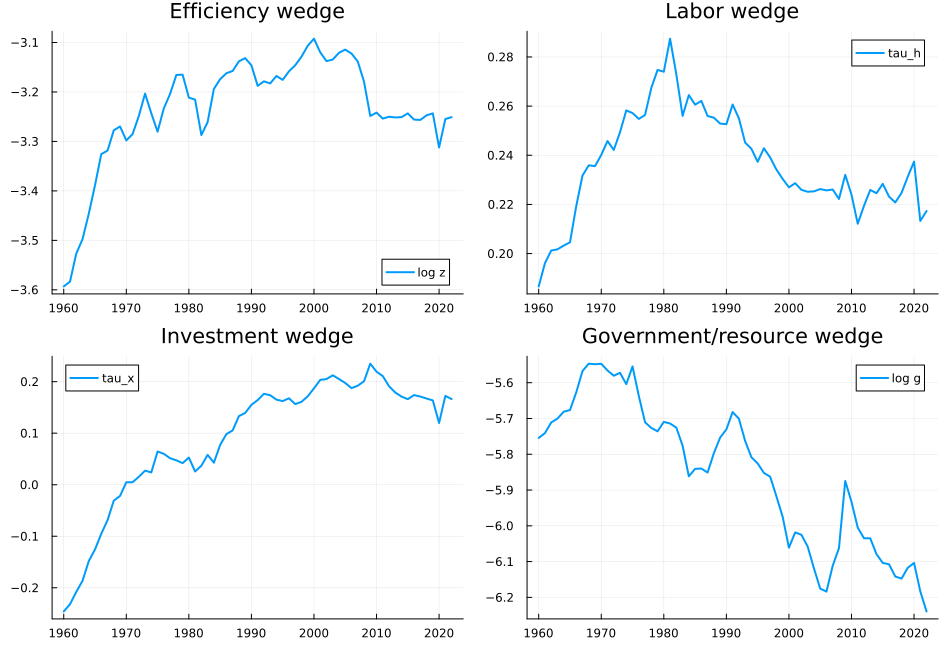

Saved wedge plot to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\figures\estimated_wedges.png


In [59]:
ENV["GKSwstype"] = "100"
using Plots
gr()

years = collect(bca_data.year)
fig_dir = joinpath(pwd(), "figures")
mkpath(fig_dir)

p1 = plot(years, wedges.log_z, title = "Efficiency wedge", label = "log z", linewidth = 2)
p2 = plot(years, wedges.tau_h, title = "Labor wedge", label = "tau_h", linewidth = 2)
p3 = plot(years, wedges.tau_x, title = "Investment wedge", label = "tau_x", linewidth = 2)
p4 = plot(years, wedges.log_g, title = "Government/resource wedge", label = "log g", linewidth = 2)

p_wedges = plot(p1, p2, p3, p4, layout = (2, 2), size = (950, 650))
wedge_plot_file = joinpath(fig_dir, "estimated_wedges.png")
savefig(p_wedges, wedge_plot_file)
println("Saved wedge plot to: ", wedge_plot_file)
display(p_wedges)

## Julia Implementation Step 10: Feed Wedges Back into the Model One at a Time

The `depression/setup.m` and `benchplots.m` files do the one-wedge accounting by changing the realized wedge states, not by changing the structural parameters. Inactive wedges are held fixed at their first-sample values. A no-shock case, with all wedges fixed at their first-sample values, is used as the baseline. For each one-wedge case, we plot the contribution relative to this no-shock baseline, normalized so the first sample year equals 100.

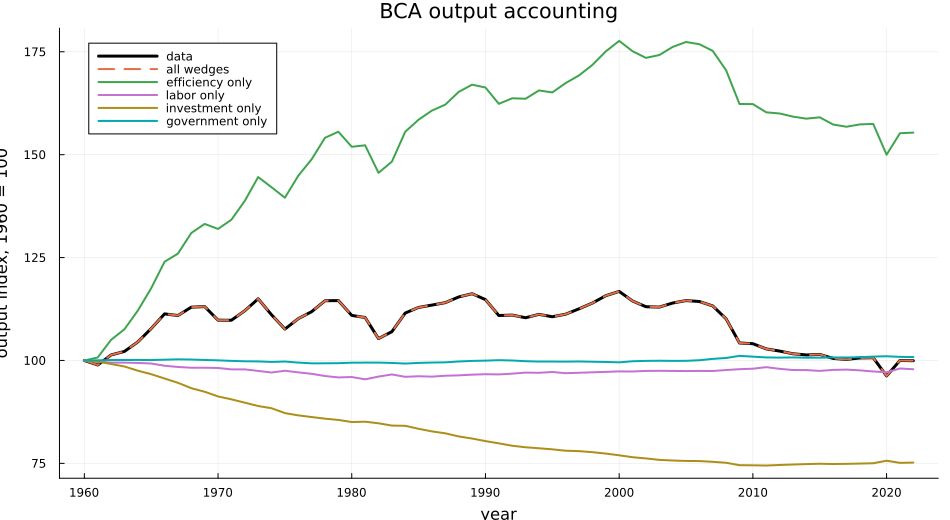

Saved output accounting plot to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\figures\one_wedge_output_accounting.png
Saved counterfactual output to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\data\hw7_bca_counterfactual_output.csv
Saved counterfactual summary to: c:\Users\30945\Desktop\Yuxuan ZHAO\minnesota\PhD_first_year\ECON8208\HW7\data\hw7_bca_counterfactual_summary.csv


Row,experiment,correlation_with_data,std_relative_to_data
,String,Float64,Float64
1,all wedges,1.0,1.0
2,no shock,-0.178408,0.684858
3,efficiency only,0.403939,2.73788
4,labor only,-0.496295,0.191972
5,investment only,0.0417324,1.77002
6,government only,-0.706778,0.0963949


In [60]:
# -------------------------------------------------------
# Step 10: one-wedge accounting via bca_one_wedge_accounting
# -------------------------------------------------------
counterfactual_output, cf_summary, level_series = bca_one_wedge_accounting(
    ss_hat, wedges, ckm_final_inputs, Yobs, years,
)

# Unpack for the subwindow plots in the next cell.
y_data_level = level_series.y_data_level
y_all_level  = level_series.y_all_level
y_no_level   = level_series.y_no_level
y_z_contrib  = level_series.y_z_contrib
y_h_contrib  = level_series.y_h_contrib
y_x_contrib  = level_series.y_x_contrib
y_g_contrib  = level_series.y_g_contrib

# --- Plot: full-sample one-wedge accounting ---
p_output = plot(years, counterfactual_output.data_index, label = "data", linewidth = 3, color = :black)
plot!(p_output, years, counterfactual_output.all_wedges_index,      label = "all wedges",       linewidth = 2, linestyle = :dash)
plot!(p_output, years, counterfactual_output.efficiency_only_index, label = "efficiency only",  linewidth = 2)
plot!(p_output, years, counterfactual_output.labor_only_index,      label = "labor only",       linewidth = 2)
plot!(p_output, years, counterfactual_output.investment_only_index, label = "investment only",  linewidth = 2)
plot!(p_output, years, counterfactual_output.government_only_index, label = "government only",  linewidth = 2)
plot!(p_output, title = "BCA output accounting", ylabel = "output index, 1960 = 100",
      xlabel = "year", size = (950, 520))

output_plot_file = joinpath(fig_dir, "one_wedge_output_accounting.png")
savefig(p_output, output_plot_file)
println("Saved output accounting plot to: ", output_plot_file)
display(p_output)

# --- CSV exports ---
cf_output_file = joinpath(data_dir, "hw7_bca_counterfactual_output.csv")
open(cf_output_file, "w") do io
    println(io, "year,data_index,all_wedges_index,no_shock_index,efficiency_only_index,labor_only_index,investment_only_index,government_only_index,data_log_deviation,all_wedges_log_deviation,no_shock_log_deviation,efficiency_only_log_deviation,labor_only_log_deviation,investment_only_log_deviation,government_only_log_deviation")
    for row in tools.eachrow(counterfactual_output)
        println(io, "$(row.year),$(row.data_index),$(row.all_wedges_index),$(row.no_shock_index),$(row.efficiency_only_index),$(row.labor_only_index),$(row.investment_only_index),$(row.government_only_index),$(row.data_log_deviation),$(row.all_wedges_log_deviation),$(row.no_shock_log_deviation),$(row.efficiency_only_log_deviation),$(row.labor_only_log_deviation),$(row.investment_only_log_deviation),$(row.government_only_log_deviation)")
    end
end

cf_summary_file = joinpath(data_dir, "hw7_bca_counterfactual_summary.csv")
open(cf_summary_file, "w") do io
    println(io, "experiment,correlation_with_data,std_relative_to_data")
    for row in tools.eachrow(cf_summary)
        println(io, "$(row.experiment),$(row.correlation_with_data),$(row.std_relative_to_data)")
    end
end

println("Saved counterfactual output to: ", cf_output_file)
println("Saved counterfactual summary to: ", cf_summary_file)
cf_summary


## Quarterly Extension: Yichen's cleaned data

Re-run the same pipeline (load → detrend → warm-start → MLE → wedge reconstruction → one-wedge accounting) on Yichen's quarterly BEA/BLS panel `data/cleaned_data_from_yichen.csv` (Q1-1948 to Q4-2024). We reuse every helper in `HW7Tools.jl`; the only differences are (i) the loader, (ii) frequency-converted deep parameters, and (iii) `_q` suffixes so the annual results stay in scope.


In [62]:
# -------------------------------------------------------
# Load Yichen's quarterly CSV and build the per-capita BCA series
# Conventions: BEA series are SAAR nominal; divide per-capita real y by 4
# to get a true quarterly flow so that y = c + x + g matches the quarterly
# perpetual-inventory law of motion.
# -------------------------------------------------------
import Pkg
if Base.find_package("CSV") === nothing; Pkg.add("CSV"); end
using CSV

raw_q  = tools.DataFrame(CSV.File(joinpath(data_dir, "cleaned_data_from_yichen.csv")))

parse_qlabel(lbl) = parse(Int, lbl[4:end]) + (parse(Int, lbl[2:2]) - 1) / 4
years_q_full = parse_qlabel.(String.(raw_q.time_label))

GDP_n_q   = Float64.(raw_q.GDP)
PGDP_q    = Float64.(raw_q.PGDP)
inv_n_q   = Float64.(raw_q.gross_investment) .+ Float64.(raw_q.durable_goods)
gov_n_q   = Float64.(raw_q.government_consumption) .+ Float64.(raw_q.net_exports)
c_n_q     = GDP_n_q .- inv_n_q .- gov_n_q
pop_q     = Float64.(raw_q.iP)

y_saar_q  = (GDP_n_q ./ PGDP_q) ./ pop_q     # SAAR real per-capita output
y_pc_q    = y_saar_q ./ 4.0                  # convert to quarterly flow
c_pc_q    = (c_n_q   ./ GDP_n_q) .* y_pc_q
x_pc_q    = (inv_n_q ./ GDP_n_q) .* y_pc_q
g_pc_q    = (gov_n_q ./ GDP_n_q) .* y_pc_q

# Hours: normalise total_worked_hours/population so 1948Q1 matches the
# annual convention (~0.25 fraction of time endowment).
h_raw_q   = Float64.(raw_q.total_worked_hours) ./ pop_q
h_pc_q    = h_raw_q .* (0.25 / h_raw_q[1])

# Capital via quarterly perpetual inventory: k[t+1] = (1-delta_q) k[t] + x[t]
delta_q_pi = 1.0 - (1.0 - 0.072)^(1/4)
k_pc_q     = similar(y_pc_q)
k_pc_q[1]  = 10.0 * y_pc_q[1]                # K/Y ~ 10 in quarterly model units
for t in 1:(length(y_pc_q) - 1)
    k_pc_q[t + 1] = (1.0 - delta_q_pi) * k_pc_q[t] + x_pc_q[t]
end

bca_data_q = tools.DataFrame(
    year   = years_q_full,
    y      = y_pc_q, c = c_pc_q, x = x_pc_q, g = g_pc_q,
    h      = h_pc_q, k_data = k_pc_q,
)
bca_data_q = filter(row -> row.y > 0 && row.c > 0 && row.x > 0 && row.g > 0 &&
                           row.h > 0 && row.h < 1 && row.k_data > 0, bca_data_q)

q_data_file = joinpath(data_dir, "hw7_bca_quarterly.csv")
open(q_data_file, "w") do io
    println(io, "year,y,c,x,g,h,k_data")
    for row in tools.eachrow(bca_data_q)
        println(io, "$(row.year),$(row.y),$(row.c),$(row.x),$(row.g),$(row.h),$(row.k_data)")
    end
end

println("Quarterly: T = ", tools.nrow(bca_data_q),
        ", ", bca_data_q.year[1], " to ", bca_data_q.year[end])
first(bca_data_q, 4)


   Resolving package versions...
    Updating `C:\Users\30945\.julia\environments\v1.12\Project.toml`
  [336ed68f] + CSV v0.10.16
    Updating `C:\Users\30945\.julia\environments\v1.12\Manifest.toml`
  [336ed68f] + CSV v0.10.16
  [48062228] + FilePathsBase v0.9.24
  [ea10d353] + WeakRefStrings v1.4.2
  [76eceee3] + WorkerUtilities v1.6.1


Quarterly: T = 308, 1948.0 to 2024.75


Row,year,y,c,x,g,h,k_data
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1948.0,0.00510988,0.00282326,0.00150534,0.000781283,0.25,0.0510988
2,1948.25,0.00518061,0.00285335,0.00156998,0.000757286,0.249903,0.0516585
3,1948.5,0.00519641,0.0028252,0.00161128,0.000759929,0.251997,0.0522724
4,1948.75,0.00518796,0.00283035,0.00158528,0.00077233,0.250377,0.0529162


In [63]:
# -------------------------------------------------------
# Quarterly calibration (frequency-converted from the annual deep params),
# detrend, Step-2 static wedges and warm-start theta0_q
# -------------------------------------------------------
hw7_params_q = (
    beta    = 0.97^(1/4),
    psi     = 1.55,
    sigma   = 2.00,
    gamma_n = (1.0 + 0.01)^(1/4) - 1.0,
    gamma_z = (1.0 + 0.02)^(1/4) - 1.0,
    theta   = 0.368,
    delta   = 1.0 - (1.0 - 0.072)^(1/4),
)

T_q       = tools.nrow(bca_data_q)
t_idx_q   = collect(0:(T_q - 1))
trend_q   = (1.0 + hw7_params_q.gamma_z) .^ t_idx_q

y_tilde_q = bca_data_q.y ./ trend_q
c_tilde_q = bca_data_q.c ./ trend_q
x_tilde_q = bca_data_q.x ./ trend_q
g_tilde_q = bca_data_q.g ./ trend_q
k_tilde_q = bca_data_q.k_data ./ trend_q
h_tilde_q = bca_data_q.h

log_g_q   = log.(g_tilde_q)
log_z_q   = (log.(y_tilde_q) .- hw7_params_q.theta .* log.(k_tilde_q) .-
             (1.0 - hw7_params_q.theta) .* log.(h_tilde_q)) ./ (1.0 - hw7_params_q.theta)
tau_h_q   = 1.0 .- (hw7_params_q.psi / (1.0 - hw7_params_q.theta)) .*
                    (c_tilde_q ./ y_tilde_q) .*
                    (h_tilde_q ./ (1.0 .- h_tilde_q))
Yobs_q    = hcat(log.(y_tilde_q), log.(x_tilde_q), log.(h_tilde_q), log_g_q)

Sbar0_q   = [tools.mean(log_z_q), tools.mean(tau_h_q), 0.0, tools.mean(log_g_q)]
P_init_q  = 0.97 .* Matrix{Float64}(I, 4, 4)
Q_init_q            = zeros(4, 4)
Q_init_q[1, 1]      = tools.std(log_z_q)
Q_init_q[2, 2]      = tools.std(tau_h_q)
Q_init_q[3, 3]      = 0.01
Q_init_q[4, 4]      = tools.std(log_g_q)
theta0_q = pack_bca_theta(Sbar0_q, P_init_q, Q_init_q)

println("T_q = ", T_q,
        "  |  data obs per MLE param = ", round(4 * T_q / 30; digits = 2))
println("log z: mean = ", tools.mean(log_z_q), ", std = ", tools.std(log_z_q))
println("tau_h: mean = ", tools.mean(tau_h_q), ", std = ", tools.std(tau_h_q))
println("log g: mean = ", tools.mean(log_g_q), ", std = ", tools.std(log_g_q))


T_q = 308  |  data obs per MLE param = 41.07
log z: mean = -5.287368692828931, std = 0.07649461735870704
tau_h: mean = 0.5447305625428509, std = 0.04394330018565965
log g: mean = -7.162893382898906, std = 0.2212191023929438


NM restart 1: neg log lik = -3666.6266925094624  iters = 3000  improvement = Inf  elapsed = 44.35s
NM restart 2: neg log lik = -3679.964619770502  iters = 3000  improvement = 13.3379  elapsed = 51.04s
NM restart 3: neg log lik = -3683.5023866522088  iters = 3000  improvement = 3.5378  elapsed = 49.42s
NM restart 4: neg log lik = -3683.909440770779  iters = 3000  improvement = 0.4071  elapsed = 48.46s
NM restart 5: neg log lik = -3684.288100657907  iters = 3000  improvement = 0.3787  elapsed = 46.32s
NM restart 6: neg log lik = -3684.358632732027  iters = 3000  improvement = 0.0705  elapsed = 52.81s
NM restart 7: neg log lik = -3684.495423715702  iters = 3000  improvement = 0.1368  elapsed = 48.12s
NM restart 8: neg log lik = -3684.7807323052125  iters = 3000  improvement = 0.2853  elapsed = 54.26s
NM restart 9: neg log lik = -3684.961124324453  iters = 3000  improvement = 0.1804  elapsed = 54.27s
NM restart 10: neg log lik = -3685.233516871327  iters = 3000  improvement = 0.2724  elaps

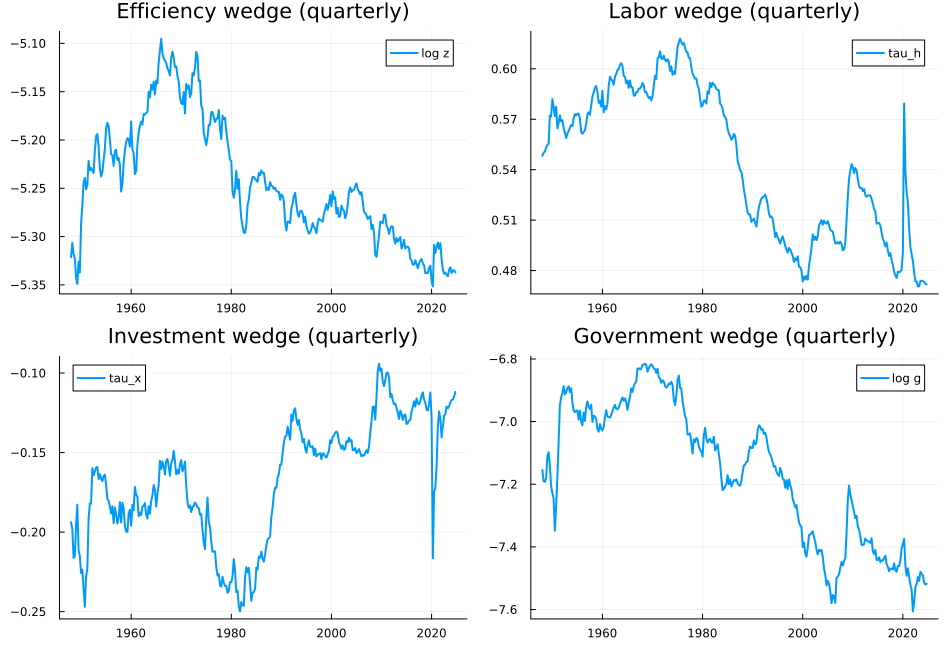

In [64]:
# -------------------------------------------------------
# Step 7+8 on quarterly data: MLE + CKM wedge reconstruction
# -------------------------------------------------------
theta_hat_q, final_neg_ll_q = estimate_bca_mle_nm(
    theta0_q, hw7_params_q, Yobs_q;
    max_restarts = 10, iterations = 3000, improve_tol = 0.1, verbose = true,
)

ss_hat_q = bca_state_space(theta_hat_q, hw7_params_q)
wedges_q, ckm_final_inputs_q = ckm_loglinear_reconstruction(
    ss_hat_q, hw7_params_q,
    y_tilde_q, x_tilde_q, h_tilde_q, g_tilde_q,
    log_g_q, bca_data_q.year,
)

println("Quarterly MLE neg log lik = ", final_neg_ll_q)
println("Estimated Sbar_q = ", ss_hat_q.Sbar)

# Save quarterly wedges to CSV
wedge_q_file = joinpath(data_dir, "hw7_bca_wedges_quarterly.csv")
open(wedge_q_file, "w") do io
    println(io, "year,log_z,tau_h,tau_x,log_g,log_z_linear,tau_h_linear")
    for row in tools.eachrow(wedges_q)
        println(io,
            "$(row.year),$(row.log_z),$(row.tau_h),$(row.tau_x),",
            "$(row.log_g),$(row.log_z_linear),$(row.tau_h_linear)")
    end
end
println("Saved quarterly wedges to: ", wedge_q_file)

yrs_q = collect(bca_data_q.year)
p1q = plot(yrs_q, wedges_q.log_z, title = "Efficiency wedge (quarterly)", label = "log z", linewidth = 2)
p2q = plot(yrs_q, wedges_q.tau_h, title = "Labor wedge (quarterly)",      label = "tau_h", linewidth = 2)
p3q = plot(yrs_q, wedges_q.tau_x, title = "Investment wedge (quarterly)", label = "tau_x", linewidth = 2)
p4q = plot(yrs_q, wedges_q.log_g, title = "Government wedge (quarterly)", label = "log g", linewidth = 2)
p_wedges_q = plot(p1q, p2q, p3q, p4q, layout = (2, 2), size = (950, 650))
savefig(p_wedges_q, joinpath(fig_dir, "estimated_wedges_quarterly.png"))
display(p_wedges_q)


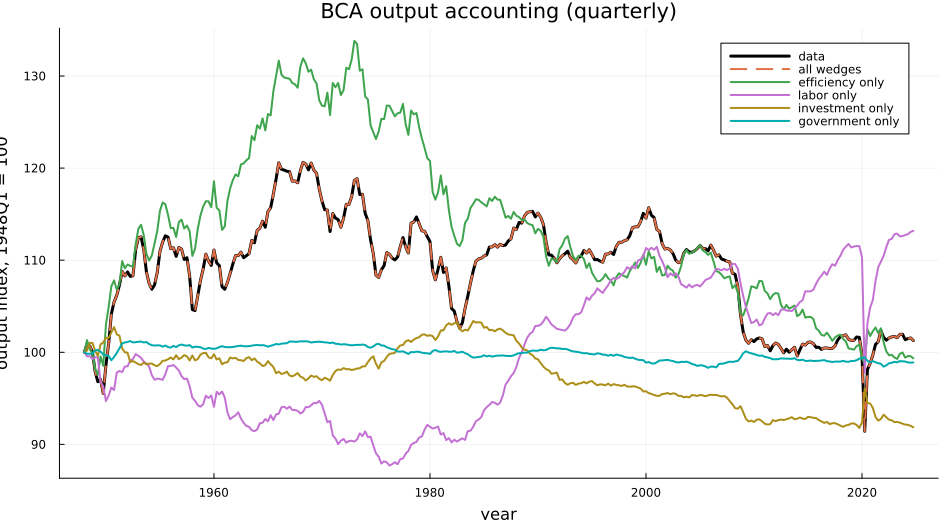

Row,experiment,correlation_with_data,std_relative_to_data
,String,Float64,Float64
1,all wedges,1.0,1.0
2,no shock,-0.108561,0.0362395
3,efficiency only,0.812093,1.48363
4,labor only,-0.392805,1.39935
5,investment only,0.431125,0.627008
6,government only,0.496101,0.144425


In [65]:
# -------------------------------------------------------
# Step 10 on quarterly data: one-wedge output accounting
# -------------------------------------------------------
counterfactual_output_q, cf_summary_q, level_series_q = bca_one_wedge_accounting(
    ss_hat_q, wedges_q, ckm_final_inputs_q, Yobs_q, yrs_q,
)

p_output_q = plot(yrs_q, counterfactual_output_q.data_index, label = "data", linewidth = 3, color = :black)
plot!(p_output_q, yrs_q, counterfactual_output_q.all_wedges_index,      label = "all wedges",      linewidth = 2, linestyle = :dash)
plot!(p_output_q, yrs_q, counterfactual_output_q.efficiency_only_index, label = "efficiency only", linewidth = 2)
plot!(p_output_q, yrs_q, counterfactual_output_q.labor_only_index,      label = "labor only",      linewidth = 2)
plot!(p_output_q, yrs_q, counterfactual_output_q.investment_only_index, label = "investment only", linewidth = 2)
plot!(p_output_q, yrs_q, counterfactual_output_q.government_only_index, label = "government only", linewidth = 2)
plot!(p_output_q, title = "BCA output accounting (quarterly)",
      ylabel = "output index, 1948Q1 = 100", xlabel = "year", size = (950, 520))
savefig(p_output_q, joinpath(fig_dir, "one_wedge_output_accounting_quarterly.png"))
display(p_output_q)

cf_summary_q
